In [1]:
import os
import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# use daily averages

In [2]:
# Define SARIMA model
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [45]:
# Forecasting 
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season = []
            
        for i in range(train_len, total_len, window):
            last_season = df_train_station1[i-window:i]
            pred_last_season.extend(last_season)
            
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df_train_station1[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [4]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df


In [5]:
#drop these two features because they mess up station 4. Temporary solution
for key in dfs.keys():
  dfs[key].drop(['SWC_50'], axis = 1, inplace = True)
  dfs[key].drop(['T_50'], axis = 1, inplace = True)


In [6]:
#drop flag feature and null values

for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  df_new.dropna(inplace=True)
  dfs[station] = df_new

In [7]:
#Vectorize wind
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [8]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

In [9]:
# create one standard metric for PPT
for key in dfs.keys():
  dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [10]:
#Normalize all the data

for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [11]:
#add geographical position data

position_dict = {"Station1": [30.3989,-98.6105],
                 "Station2": [30.4193,-98.8046],
                 "Station3": [30.4421,-98.8427],
                 "Station4": [30.4600, -98.9407],
                 "Station5": [30.2454,-98.7059],
                 "Station6": [30.2758,-98.7242]
                 }

for key in dfs.keys():
  dfs[key]["Latitude"] = position_dict[key][0]
  dfs[key]["Longitude"] = position_dict[key][1]

In [12]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


45185


# Create Multi-Index DF for all Station Data

In [13]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [14]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [15]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [16]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 T_5,Station1 T_10,Station1 T_20,Station1 Tair,Station1 RH,Station1 Srad,Station1 Wx,...,Station6 Srad,Station6 Wx,Station6 Wy,Station6 Day sin,Station6 Day cos,Station6 Year sin,Station6 Year cos,Station6 PPT,Station6 Latitude,Station6 Longitude
2016-02-20 13:00:00,0.139623,0.219626,0.208054,0.409553,0.414440,0.417014,0.912188,0.870606,0.350557,0.318500,...,0.326054,0.327554,0.519249,0.370590,0.017037,0.881128,0.823638,0.0,30.2758,-98.7242
2016-02-20 15:00:00,0.143396,0.224299,0.208054,0.451220,0.447961,0.434964,0.917929,0.812634,0.367328,0.353486,...,0.380189,0.385141,0.561426,0.146447,0.146447,0.881591,0.823091,0.0,30.2758,-98.7242
2016-02-20 16:00:00,0.147170,0.228972,0.214765,0.463618,0.462260,0.445890,0.924424,0.799389,0.392486,0.368937,...,0.443144,0.382056,0.563651,0.066987,0.250000,0.881823,0.822818,0.0,30.2758,-98.7242
2016-02-20 17:00:00,0.143396,0.228972,0.208054,0.468089,0.472808,0.456296,0.927341,0.797453,0.213525,0.369872,...,0.196865,0.413326,0.599024,0.017037,0.370590,0.882054,0.822544,0.0,30.2758,-98.7242
2016-02-20 18:00:00,0.143396,0.228972,0.214765,0.457317,0.476090,0.465140,0.924894,0.823484,0.078887,0.390298,...,0.076036,0.429337,0.603361,0.000000,0.500000,0.882285,0.822270,0.0,30.2758,-98.7242


In [17]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

In [18]:
df.tail()

Station              Station1                                           
Feature                 SWC_5    SWC_10    SWC_20       T_5      T_10   
2021-06-06 09:00:00  0.758491  0.551402  0.718121  0.455285  0.498594  \
2021-06-06 10:00:00  0.758491  0.546729  0.711409  0.468496  0.505860   
2021-06-06 11:00:00  0.758491  0.546729  0.711409  0.498984  0.518987   
2021-06-06 12:00:00  0.754717  0.546729  0.711409  0.554472  0.550398   
2021-06-06 13:00:00  0.747170  0.546729  0.711409  0.601829  0.588608   

Station                                                                ...   
Feature                  T_20      Tair        RH      Srad        Wx  ...   
2021-06-06 09:00:00  0.533559  0.920141  0.941416  0.180612  0.335740  ...  \
2021-06-06 10:00:00  0.534860  0.924188  0.906775  0.308349  0.347136  ...   
2021-06-06 11:00:00  0.539282  0.935012  0.863627  0.737477  0.315928  ...   
2021-06-06 12:00:00  0.549688  0.942259  0.838767  0.885900  0.310358  ...   
2021-06-06 13:00:00  0.569199  0.946776  0.833316  0.927644  0.299121  ...   

Station              Station6                                           
Feature                  Srad        Wx        Wy   Day sin   Day cos   
2021-06-06 09:00:00  0.152973  0.409350  0.608478  0.853553  0.146447  \
2021-06-06 10:00:00  0.430991  0.449031  0.668760  0.750000  0.066987   
2021-06-06 11:00:00  0.777477  0.375301  0.659724  0.629410  0.017037   
2021-06-06 12:00:00  0.873874  0.372571  0.608229  0.500000  0.000000   
2021-06-06 13:00:00  0.881982  0.353124  0.652895  0.370590  0.017037   

Station                                                          
Feature              Year sin  Year cos  PPT Latitude Longitude  
2021-06-06 09:00:00  0.713254  0.047758  0.0  30.2758  -98.7242  
2021-06-06 10:00:00  0.712929  0.047605  0.0  30.2758  -98.7242  
2021-06-06 11:00:00  0.712605  0.047453  0.0  30.2758  -98.7242  
2021-06-06 12:00:00  0.712281  0.047300  0.0  30.2758  -98.7242  
2021-06-06 13:00:00  0.711956  0.047148  0.0  30.2758  -98.7242  

[5 rows x 108 columns]

In [19]:
df.index = pd.to_datetime(df.index)
df = df.resample('M').mean()

# Data Split

In [23]:
num_predictions = 10
total_len = len(df.Station1.SWC_5)
train_len = total_len - num_predictions
test_len = num_predictions

In [24]:
df_train_station1 = df.Station1.SWC_5[:train_len]
df_test_station1 = df.Station1.SWC_5[train_len:]
df_total_station1 = df.Station1.SWC_5

In [61]:
# Define range of parameter's to check
ps = range(0, 3, 1)
qs = range(0, 3, 1)
Ps = range(0, 3, 1)
Qs = range(0, 3, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12

In [62]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(df_train_station1, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/81 [00:00<?, ?it/s]

[(0, 0, 0, 0), 58.91812616616237]
[(0, 0, 0, 1), 21.289169830535297]
[(0, 0, 0, 2), 3.5227630379754813]
[(0, 0, 1, 0), -34.43830709964714]
[(0, 0, 1, 1), -40.26577507467853]
[(0, 0, 1, 2), -39.10380150892929]
[(0, 0, 2, 0), -40.01608428132745]
[(0, 0, 2, 1), -39.07633121578593]
[(0, 0, 2, 2), -36.96205634085284]
[(0, 1, 0, 0), 12.034647632189607]
[(0, 1, 0, 1), -9.077903033225015]
[(0, 1, 0, 2), -17.622384369756627]
[(0, 1, 1, 0), -39.107605195587105]
[(0, 1, 1, 1), -45.27308019077346]
[(0, 1, 1, 2), -43.607904367066894]
[(0, 1, 2, 0), -44.1601890902069]
[(0, 1, 2, 1), -43.607619138274366]
[(0, 1, 2, 2), -41.66099149041046]
[(0, 2, 0, 0), -25.04257796230475]
[(0, 2, 0, 1), -35.28897013908716]
[(0, 2, 0, 2), -37.368379574547305]
[(0, 2, 1, 0), -47.39202471767427]
[(0, 2, 1, 1), -31.32854709929741]
[(0, 2, 1, 2), -48.20381633314244]
[(0, 2, 2, 0), -48.53422953723225]
[(0, 2, 2, 1), -48.14632229579951]
[(0, 2, 2, 2), -46.21339447095224]
[(1, 0, 0, 0), -67.08011586931934]
[(1, 0, 0, 1), -6

,"(p,q,P,Q)",AIC
0,"(2, 1, 0, 0)",-73.307492
1,"(2, 1, 0, 1)",-72.928043
2,"(2, 1, 0, 2)",-70.997542
3,"(1, 2, 1, 0)",-70.854496
4,"(2, 1, 1, 0)",-70.614909
...,...,...
76,"(0, 1, 0, 1)",-9.077903
77,"(0, 0, 0, 2)",3.522763
78,"(0, 1, 0, 0)",12.034648
79,"(0, 0, 0, 1)",21.289170


In [63]:
SARIMA_result_df

,"(p,q,P,Q)",AIC
0,"(2, 1, 0, 0)",-73.307492
1,"(2, 1, 0, 1)",-72.928043
2,"(2, 1, 0, 2)",-70.997542
3,"(1, 2, 1, 0)",-70.854496
4,"(2, 1, 1, 0)",-70.614909
...,...,...
76,"(0, 1, 0, 1)",-9.077903
77,"(0, 0, 0, 2)",3.522763
78,"(0, 1, 0, 0)",12.034648
79,"(0, 0, 0, 1)",21.289170


In [64]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(df_train_station1, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  SWC_5   No. Observations:                   55
Model:               SARIMAX(2, 0, 1)   Log Likelihood                  39.431
Date:                Tue, 29 Aug 2023   AIC                            -70.861
Time:                        10:35:21   BIC                            -62.980
Sample:                    02-29-2016   HQIC                           -67.830
                         - 08-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4856      0.176      8.460      0.000       1.141       1.830
ar.L2         -0.4865      0.174     -2.797      0.005      -0.827      -0.146
ma.L1         -0.9997     22.235     -0.045      0.9

In [65]:
pred_df = df_test_station1.copy()

In [66]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len/5)

In [67]:
pred_df['SARIMA'] = rolling_forecast(df_total_station1, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

In [68]:
pred_df['last_season'] = rolling_forecast(df_train_station1, TRAIN_LEN, HORIZON, WINDOW, 'last_season')

In [69]:
pred_df

2020-09-30 00:00:00                                             0.539213
2020-10-31 00:00:00                                             0.222048
2020-11-30 00:00:00                                             0.228239
2020-12-31 00:00:00                                             0.379884
2021-01-31 00:00:00                                             0.612979
2021-02-28 00:00:00                                             0.589847
2021-03-31 00:00:00                                             0.418117
2021-04-30 00:00:00                                             0.299581
2021-05-31 00:00:00                                             0.581076
2021-06-30 00:00:00                                             0.766601
SARIMA                 [0.26688599488216064, 0.3226998186709626, 0.35...
last_season                   [0.17631872590789208, 0.15623858794887402]
Name: SWC_5, dtype: object

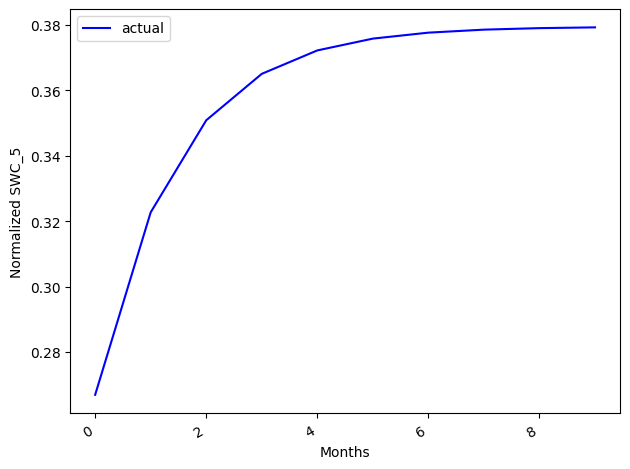

In [74]:
# visualize predictions
fig, ax = plt.subplots()

# ax.plot(df_total_station1)
ax.plot(pred_df.SARIMA, 'b-', label='actual')
# ax.plot(pred_df[:10], 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

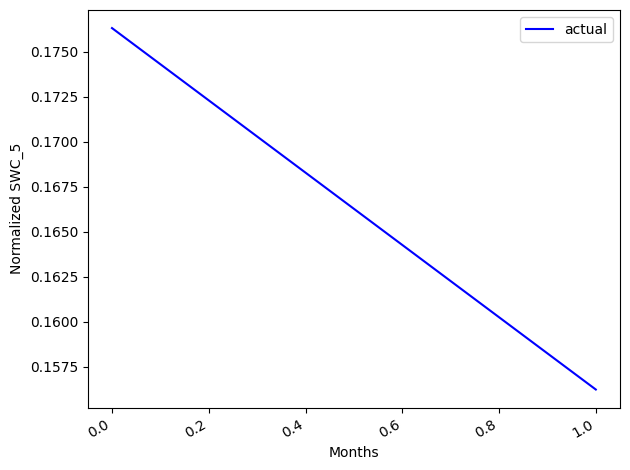

In [71]:
# visualize predictions
fig, ax = plt.subplots()

# ax.plot(df_total_station1)
ax.plot(pred_df.last_season, 'b-', label='actual')
# ax.plot(pred_df[:10], 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [72]:
# Evaluate 
mse=np.mean((pred_df[:10]-pred_df.SARIMA)**2)
mse

0.040204034710550896